In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from src.engineering import create_fraud_features

In [5]:

import warnings

#Ignore warnings to keep the output clean
#warnings.filterwarnings('ignore')

%matplotlib inline

#base libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

#Data splitting and Cross-validation tools
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold, TimeSeriesSplit

#Data Pipeline and Preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer,MissingIndicator
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, TargetEncoder
from sklearn.cluster import KMeans

#ML models
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor, IsolationForest

#Evaluation metrics we might use
from sklearn.metrics import (
    classification_report, make_scorer, fbeta_score, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve,
    mean_squared_error, r2_score, mean_absolute_error,silhouette_score)

print("libraries imported successfully")


libraries imported successfully


/home/daniel/python/DS_projects/Credit_card_fraud/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


at first we would want to have a look on the data and see what anomalies we have, in general to see what part of the data we want to take care in a special way

In [7]:
df = pd.read_csv('Base_unlabeled.csv')
how_many_10 = (df['customer_age'] == 10).sum()/len(df)*100
#print(how_many_10)

#answer is 2% so there isn't a lot of 10 year olds in the dataset. We will keep them in the dataset for now.



from itertools import combinations


# 1. Define your target columns
target_cols = [
    "current_address_months_count",
    "credit_risk_score",
    "session_length_in_minutes",
    "device_distinct_emails_8w",
    "prev_address_months_count",
]

# 2. Loop through every unique pair and count the matches
pair_counts = {}
list_pairs = list(combinations(target_cols, 2))
for col1, col2 in combinations(target_cols, 2):
    # Check where both columns equal -1 in the same row
    match_count = ((df[col1] == -1) & (df[col2] == -1)).sum()

    # Store the result with a readable pair name
    pair_counts[f"{col1} & {col2}"] = match_count

# 3. Convert the results into a clean DataFrame for easy viewing
results_df = pd.DataFrame(
    list(pair_counts.items()), columns=["Column Pair", "Row Count"]
)
#print(results_df)


#checking the number of missing values in each target column
total_num = []
missing_values = df[target_cols] == -1
missing_values = missing_values.sum()



# 1. Split the "Column Pair" string into two separate temporary column names
results_df["Col1"] = results_df["Column Pair"].apply(
    lambda x: x.split(" & ")[0].strip()
)
results_df["Col2"] = results_df["Column Pair"].apply(
    lambda x: x.split(" & ")[1].strip()
)
#print(results_df)

# 2. Use your existing 'missing_values' Series to look up the totals
results_df["Col1_Total_-1"] = results_df["Col1"].map(missing_values)
results_df["Col2_Total_-1"] = results_df["Col2"].map(missing_values)

# 3. Calculate the percentages
results_df["% of Col1 rows"] = (
    results_df["Row Count"] / results_df["Col1_Total_-1"]
) * 100
results_df["% of Col2 rows"] = (
    results_df["Row Count"] / results_df["Col2_Total_-1"]
) * 100

# 4. Create the clean final DataFrame
percentage_df = results_df[
    [
        "Column Pair",
        "Row Count",
        "Col1_Total_-1",
        "Col2_Total_-1",
        "% of Col1 rows",
        "% of Col2 rows",
    ]
]
print(percentage_df.round(2))

def calculate_lift(row):
    lift_1_to_2 = (row["% of Col2 rows"]/row["Col1_Total_-1"])*10000  
    lift_2_to_1 = (row["% of Col1 rows"]/row["Col2_Total_-1"])*10000  
    
    return pd.Series({'lift_1_to_2': lift_1_to_2, 'lift_2_to_1': lift_2_to_1})
lift_df = pd.DataFrame()
lift_df[['lift_1_to_2', 'lift_2_to_1']] = calculate_lift(percentage_df)

print(lift_df.round(2))



print(total_num)

print(missing_values)




# We see that for 60% of the missing values of "device_distinct_emails_8w" there is also a missing value in "session_length_in_minutes", maybe indicating a relationship between the two. We will keep this in mind for later analysis.

# We see indeed that "prev_address_months_count" has a lot of missing values, yet no relation between it's missing values and the other target columns. Our assumption is that this column is not very useful for our analysis and we will drop it from the dataset.

df = df.drop("prev_address_months_count", axis=1) #dropping this column because it has too many missing values



FileNotFoundError: [Errno 2] No such file or directory: 'Base_unlabeled.csv'

In [2]:
#the raw data we will be working with
df = pd.read_csv('Base_unlabeled.csv')



In [9]:
#have a first look on the dataset, checking for some wierd column names, or wierd values
#df.head()

#Having a look at the dataset's information, summary statistics, target variable distribution, and missing values to get a better understanding of the data
#df.info()

#Having a look at the dataset's summary statistics, target variable distribution, and missing values to get a better understanding of the data
#df.describe(include='all')


mask = df['velocity_24h'] > df['velocity_4w']
print(f"Violations: {mask.sum()} rows ({mask.mean()*100:.2f}%)")
df[mask].head()


sns.histplot(df['balance_to_income_ratio'], bins=50)
plt.title('Balance to Income Ratio Distribution')
plt.show()
threshold = df['balance_to_income_ratio'].quantile(0.90)
print(f"90th percentile: {threshold:.2f}")
# Get the 90th percentile threshold
threshold_90 = df['balance_to_income_ratio'].quantile(0.90)

# Filter rows above 90th percentile
high_ratio = df[df['balance_to_income_ratio'] > threshold_90]

# Check how many of those also have velocity violation
velocity_violation = high_ratio[high_ratio['velocity_6h'] > high_ratio['velocity_24h']]

print(f"Rows above 90th percentile: {len(high_ratio)}")
print(f"Of those, velocity violations: {len(velocity_violation)}")
print(f"Percentage: {len(velocity_violation)/len(high_ratio)*100:.2f}%")
sns.histplot(df['zip_count_4w'], bins=500)
plt.title('Zip Count 4W Distribution')
plt.show()
print(f"Mean: {df['zip_count_4w'].mean():.2f}")
print(f"Variance: {df['zip_count_4w'].var():.2f}")
# Define thresholds at 95th percentile
balance_threshold = df['balance_to_income_ratio'].quantile(0.95)
zip_threshold = df['zip_count_4w'].quantile(0.95)

# Create flags
high_balance = df['balance_to_income_ratio'] > balance_threshold
high_zip = df['zip_count_4w'] > zip_threshold

# Probabilities
p_high_zip = high_zip.mean()
p_high_balance = high_balance.mean()
p_both = (high_balance & high_zip).mean()
p_high_balance_given_high_zip = (high_balance & high_zip).sum() / high_zip.sum()

print(f"P(high zip 95th): {p_high_zip:.4f}")
print(f"P(high balance ratio 95th): {p_high_balance:.4f}")
print(f"P(both): {p_both:.4f}")
print(f"P(high balance | high zip): {p_high_balance_given_high_zip:.4f}")

lift = p_high_balance_given_high_zip / p_high_balance
print(f"\nLift: {lift:.2f}x")
print("→ Strong correlation — likely same fraud pattern" if lift > 1.5 else "→ Independent signals")


#heat map was built with the help of AI
num_cols = ['income', 'name_email_similarity', 'prev_address_months_count',
            'current_address_months_count', 'customer_age', 'days_since_request',
            'intended_balcon_amount', 'zip_count_4w', 'velocity_6h',
            'velocity_24h', 'velocity_4w', 'bank_months_count',
            'proposed_credit_limit', 'session_length_in_minutes',
            'balance_to_income_ratio']

corr_matrix = df[num_cols].corr().abs()
corr_matrix = df[num_cols].corr().abs()

# Get upper triangle only to avoid duplicates
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs with correlation above 0.5
high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.5]

high_corr_df = pd.DataFrame(high_corr, columns=['Feature1', 'Feature2', 'Correlation'])
print(high_corr_df.sort_values('Correlation', ascending=False))

# Only plot columns that actually have high correlation

relevant_cols = list(set(high_corr_df['Feature1'].tolist() + high_corr_df['Feature2'].tolist()))

sns.heatmap(df[relevant_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('High Correlation Features')
plt.show()





# Recreate balance_to_income_ratio after cleaning
df['balance_to_income_ratio'] = df['intended_balcon_amount'] / df['income']

print(f"Rows after cleaning: {len(df)}")

Violations: 440147 rows (44.01%)


KeyError: 'balance_to_income_ratio'

Writing the results appearing from the first view of the data

I decided to remove prev_address_month_count from the dataset because it had 71% of unknown data so we couldn't use it, now because we try to find  outliers we will use KNNImputer to clean our rmaining uncleaned data. 
First in order to make the neighbours average worth something we would scale the data using standardscaler since it affects less the outliers.

We notice 2 interesting things from the graphs:
From the first graph we see that as we assumed most of the balance to income ratio sits near 0, but we see a bump around 1000 which could be a sign for frauds since where did the money came from?
Secondly: when we look at the zip codes population we see a bump near 2600, maybe this is also a sign that the frauds occured there

In [3]:
#creating the balance to income ratio feature

df['balance_to_income_ratio'] = df['intended_balcon_amount'] / df['income']

print(df['balance_to_income_ratio'].describe())

count    1000000.000000
mean          24.045123
std           83.728224
min         -129.946508
25%           -2.571247
50%           -1.299149
75%            8.865805
max         1119.684953
Name: balance_to_income_ratio, dtype: float64


In [11]:
#Data cleaning
target_cols = [
    "current_address_months_count",
    "credit_risk_score",
    "session_length_in_minutes",
    "device_distinct_emails_8w",
    ]
#print("Before scaling:")
#print(df[target_cols].head())
df[target_cols] = df[target_cols].replace(-1, np.nan)   # Ensure -1 is treated as NaN for imputation
missing_mask = df[target_cols].isna().any(axis=1)
mask_rows = df[missing_mask].copy()  # Store rows with missing values for later analysis

df[target_cols] = StandardScaler().fit_transform(df[target_cols])

import time
sample = df[target_cols].sample(10000, random_state=1)
start = time.time()
KNNImputer(n_neighbors=5).fit_transform(sample)
print(time.time() - start)
#print(df[target_cols].head())

## Now we can proceed for the KNNImputer for the missing values in the target columns. We will use KNNImputer to fill in the missing values based on the nearest neighbors.

df[target_cols] = KNNImputer(n_neighbors=5).fit_transform(df[target_cols]) #we don't want to miss outliers so we leave the n_neighbors to 5.
print("mask_rows:")
print(df.loc[missing_mask.index[missing_mask]].copy())
print(mask_rows.head())


0.025952816009521484


KeyboardInterrupt: 

In [12]:

#print(df.corr(numeric_only=True))

# Checking the relation between prev_adress_month_count to curr_adress_month_count

rows = (df['prev_address_months_count'] != -1) & (df['current_address_months_count'] != -1)
mask = df.loc[rows, ['prev_address_months_count', 'current_address_months_count']]
print(mask.corr(numeric_only=True))


KeyError: 'prev_address_months_count'

In [4]:

#removing the prev_address_months_count column since it has too many missing values and doesn't seem to have a strong correlation with other features.
df = df.drop("prev_address_months_count", axis=1) #dropping this

checking the correlations between the numerical columns gave us some insights:
there's a strong correlation credit risk score and a proposed credit limit which makes a lot of sence given these two columns were given from the bank data and are related.
we also checked weather the correlation between the prev_adress_month_count and the curr_adress_month_count is just due to missing data or a deeper conclusion. resulting a correlation of 0.12 which is a weak one and then not a strong data insight.
after this check we decided to impute the missing Numerical data using the simple imputer with median because of the big outliers presented earlier


In [ ]:
# dealing the categorical columns



In [2]:
#Basic raw algorithm for the dataset using cluster analysis to get a baseline performance metric for the model
num_cols = ['income', 'name_email_similarity',
            'current_address_months_count', 'customer_age', 'days_since_request',
            'intended_balcon_amount','zip_count_4w','velocity_6h','velocity_24h','velocity_4w','bank_months_count','bank_branch_count_8w',
            'proposed_credit_limit','date_of_birth_distinct_emails_4w', 'session_length_in_minutes',
            'balance_to_income_ratio', 'device_distinct_emails_8w']

cat_cols = ['payment_type', 'source','employment_status', 'device_os','housing_status']

binary_cols = ['phone_home_valid','phone_mobile_valid','email_is_free', 'foreign_request', 'has_other_cards',
            'keep_alive_session']



In this part I mention which columns I decided to ignore since I didn't find any important data in them or I didn't have enough time to go through it too.
Now we are going to build the pipeline.
Since we found big outliers in the relevant data I decided to use robust scaling, for the numeric columns, since we only have 3 categorical columns we can use the HotOneEncoder for them because it won't add a lot of information, and then we are going to try and find anomalies using Anomaly forest 
Finally we will try to see if there is any correlations between the anomalies the model finds us to the data we know can be very crucial for finding credt card frauds.
As mentioned before, in this case False positive cases are much more importent to find then the False negative cases (We all prefer to recive a wrong mail for a fraud than having our money stolen) so we will use a solver simillar to f1 with a larger recall coeficient comaring to the precision coefficient.
we chose contamination to be at least 0.05 because we assume the number of credit fraud is much lower so the threshold is low enough we dont have False negatives.

In [ ]:
#First we're going to create a preprocessing pipeline for the KMeans model.
sentinel_cols = ['current_address_months_count', 'bank_months_count', 
                 'session_length_in_minutes', 'device_distinct_emails_8w']  
# whichever columns actually use -1 as "missing"
df[sentinel_cols] = df[sentinel_cols].replace(-1, np.nan)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
    
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

Binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('bin', Binary_transformer, binary_cols)
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KMeans(random_state=42, n_clusters=5, n_init=10, max_iter=300))
])

print('pipeline created successfully')



pipeline created successfully


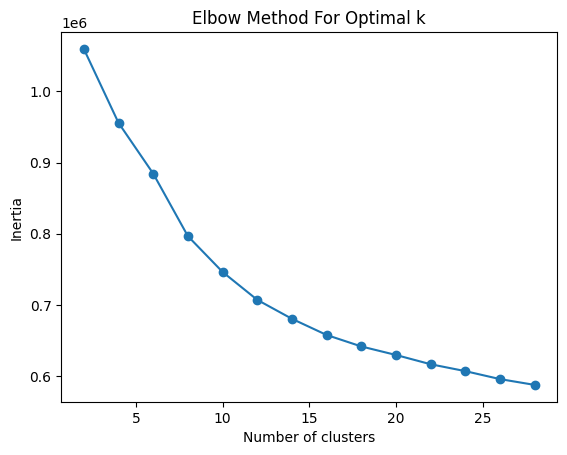

In [ ]:
# creating the elbow algorithm to find the optimal number of clusters for the KMeans model
sample = df.sample(50000,random_state=42)
inertias = []
sample = sample.replace(-1, np.nan)  # Ensure -1 is treated as NaN for imputation

for k in range(2, 30,2):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', KMeans(random_state=42, n_clusters=k, n_init=10))])
    pipeline.fit(sample)
    inertias.append(pipeline.named_steps['model'].inertia_)
plt.plot(range(2, 30,2), inertias, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

as we can see, the elbow method didn't really gave us a clear number of clusters which means most of the data is probably continous, so we will try a silhouette score method to check weather we can find an optimal k from there

In [ ]:
#silhouette score to find the optimal number of clusters for the KMeans model

sil_sample = df.sample(10000, random_state=42)   # smaller — silhouette is O(n²)-ish
X = preprocessor.fit_transform(sil_sample)        # preprocess ONCE, outside the loop

sil_scores = []
k_range = range(2, 30,2)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    print(k, round(score, 4))

plt.plot(list(k_range), sil_scores, marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette score'); plt.title('Silhouette vs k')
plt.show()

2 0.0778
4 0.0745
6 0.0776
8 0.0748
10 0.0735
12 0.0785
14 0.0809
16 0.0713
18 0.0732
20 0.0736
22 0.0691
24 0.0701
26 0.065


KeyboardInterrupt: 

As we can see, silhouette also doesn't give us a good results, meaning that either our model is not strong enough or that the model takes to many columns

Let's try dimentionality reducing to see if our problem is that in too many dimentions dots become too close, if it doesn't work we will go for a stronger model

In [ ]:
#now we remove columns that we think are not useful for the model, and we will create a new pipeline with the remaining columns.
num_cols = ['income',
            'current_address_months_count', 'customer_age', 'days_since_request',
            'zip_count_4w','velocity_6h','bank_months_count','bank_branch_count_8w',
            'proposed_credit_limit','date_of_birth_distinct_emails_4w',
            'balance_to_income_ratio', 'device_distinct_emails_8w']

cat_cols = ['payment_type','device_os','housing_status']

binary_cols = ['phone_home_valid','phone_mobile_valid', 'foreign_request', 'has_other_cards']



In [ ]:

#inserting less information to the pipeline to see if we have dimentionality issues
sentinel_cols = ['current_address_months_count', 'bank_months_count', 
                 'session_length_in_minutes', 'device_distinct_emails_8w']  
# whichever columns actually use -1 as "missing"
df[sentinel_cols] = df[sentinel_cols].replace(-1, np.nan) # Replace -1 with NaN for preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
    
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

Binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('bin', Binary_transformer, binary_cols)
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KMeans(random_state=42, n_clusters=5, n_init=10, max_iter=300))
])

print('pipeline created successfully')



pipeline created successfully


In [ ]:
#silhouette score to find the optimal number of clusters for the KMeans model

sil_sample = df.sample(10000, random_state=42)   # smaller — silhouette is O(n²)-ish
X = preprocessor.fit_transform(sil_sample)        # preprocess ONCE, outside the loop

sil_scores = []
k_range = range(2, 30,2)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    print(k, round(score, 4))

plt.plot(list(k_range), sil_scores, marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette score'); plt.title('Silhouette vs k')
plt.show()

2 0.0736
4 0.0721
6 0.0809
8 0.0673
10 0.0813


KeyboardInterrupt: 

We can see that reduce dimentionality didn't help us clustering, so we derive that perhaps, KMeans model is not accurate enough for our data and we need to work with a stronger one. 
First we are going to try IsolationForest with different contamination percentile.

In [12]:
#Basic raw algorithm for the dataset using cluster analysis to get a baseline performance metric for the model
num_cols = ['income', 'name_email_similarity',
            'current_address_months_count', 'customer_age', 'days_since_request',
            'intended_balcon_amount','zip_count_4w','velocity_6h','velocity_24h','velocity_4w','bank_months_count','bank_branch_count_8w',
            'proposed_credit_limit','date_of_birth_distinct_emails_4w', 'session_length_in_minutes',
            'balance_to_income_ratio', 'device_distinct_emails_8w']

cat_cols = ['payment_type', 'source','employment_status', 'device_os','housing_status']

binary_cols = ['phone_home_valid','phone_mobile_valid','email_is_free', 'foreign_request', 'has_other_cards',
            'keep_alive_session']




In [35]:
df['balance_to_income_ratio'] = df['intended_balcon_amount'] / df['income']
#Replacing the preprocessing pipeline to Isolation Forest model for anomaly detection
sentinel_cols = ['current_address_months_count', 'bank_months_count', 
                 'session_length_in_minutes', 'device_distinct_emails_8w']  
# whichever columns actually use -1 as "missing"
df[sentinel_cols] = df[sentinel_cols].replace(-1, np.nan)  # Replace -1 with NaN for preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
    
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

Binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('bin', Binary_transformer, binary_cols)
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', IsolationForest(random_state=42, contamination='auto', n_estimators=100, n_jobs=-1))
])

print('pipeline created successfully')



pipeline created successfully


In [36]:
sample = df.sample(10000, random_state=42)
full_pipeline.fit(sample)
print('fit OK')
full_pipeline.fit(df)



fit OK


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
#checking for NaNs in the transformed data to ensure that the preprocessing pipeline is working correctly and that there are no missing values after transformation.
transformed = full_pipeline.named_steps['preprocessor'].transform(df)
print("NaNs in transformed data:", np.isnan(transformed).sum())  # should be 0


NaNs in transformed data: 0


In [37]:
scores = full_pipeline.named_steps['model'].score_samples(
    full_pipeline.named_steps['preprocessor'].transform(df)
)
chk = df.iloc[scores.argsort()[:1000]]  # Show the 1000 most anomalous rows


In [ ]:
chk.to_csv('anomalous_rows.csv', index=False)  # Save to CSV for further analysis
import os
print(os.getcwd())


/home/daniel/Desktop


In [10]:
#adding the negative anomaly score to the dataframe for further analysis
df['anomaly_score'] = scores

In [ ]:
chk_describe = chk.describe()
chk.describe()   
#chk_describe.to_csv('anomalous_rows_describe.csv', index=False)  # Save to CSV for further analysis


,income,name_email_similarity,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,...,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,balance_to_income_ratio,anomaly_score
count,1000.000000,1000.000000,999.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,761.000000,1000.000000,1000.00000,1000.00000,869.000000,1000.000000,994.000000,1000.000000,1000.000000
mean,0.319500,0.461389,168.447447,45.070000,6.969986,45.695284,2074.369000,6940.610785,5473.536721,5314.813693,...,0.331000,16.417871,0.392000,632.23000,0.23200,12.086812,0.329000,0.936620,289.595695,-0.587933
std,0.283284,0.305814,126.787512,16.476242,14.948552,41.150910,1424.044278,3531.185492,1537.647159,941.093394,...,0.470809,11.165567,0.488441,568.80037,0.42232,14.256712,0.470085,0.579098,342.634281,0.009742
min,0.100000,0.000210,0.000000,10.000000,0.000027,-6.254069,250.000000,463.313170,1816.412437,3017.965432,...,0.000000,1.000000,0.000000,200.00000,0.00000,0.037386,0.000000,0.000000,-62.540685,-0.637606
25%,0.100000,0.163264,46.000000,30.000000,0.009821,-0.621978,1036.500000,4085.189147,4368.362177,4795.822800,...,0.000000,5.000000,0.000000,200.00000,0.00000,3.749044,0.000000,1.000000,-1.341156,-0.592861
50%,0.200000,0.470947,156.000000,50.000000,0.024900,40.406478,1450.500000,7006.366531,5547.663057,5339.551315,...,0.000000,15.000000,0.000000,200.00000,0.00000,5.967340,0.000000,1.000000,141.607476,-0.585118
75%,0.500000,0.737402,270.500000,60.000000,8.364695,96.958684,2881.250000,9159.402832,6565.882850,5975.979650,...,1.000000,28.000000,1.000000,1500.00000,0.00000,14.856659,1.000000,1.000000,497.479554,-0.580575
max,0.900000,0.999735,410.000000,90.000000,75.295243,110.538425,6506.000000,16122.237270,9415.986959,6863.086507,...,1.000000,31.000000,1.000000,2000.00000,1.00000,77.396428,1.000000,2.000000,1105.384251,-0.576851


In [ ]:
df_describe = df.describe()   
df_describe.to_csv('full_dataset_describe.csv', index=False)  # Save to CSV for further analysis

Now we are going to make a Logistic Regression model and checking how much this model is more accurate than the Isolation forest model

In [18]:
df = pd.read_csv('Base.csv')
df['balance_to_income_ratio'] = df['intended_balcon_amount'] / df['income']
df['balance_to_income_ratio'] = df['balance_to_income_ratio'].replace([np.inf, -np.inf], np.nan)
#pipeline for the logistic regression model
sentinel_cols = ['current_address_months_count', 'bank_months_count', 
                 'session_length_in_minutes', 'device_distinct_emails_8w']  
# whichever columns actually use -1 as "missing"
df[sentinel_cols] = df[sentinel_cols].replace(-1, np.nan)  # Replace -1 with NaN for preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

Binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
    ('bin', Binary_transformer, binary_cols)
])



print('pipeline created successfully')




pipeline created successfully


In [31]:
from sklearn.model_selection import train_test_split


X = df[binary_cols + num_cols + cat_cols]  # Load your dataset
y = df['fraud_bool']  # Load your target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)  # Stratified split to maintain class distribution

Xt = preprocessor.fit_transform(X_train)
col_max = np.abs(Xt).max(axis=0)
worst = np.argsort(col_max)[-5:]
print("worst column indices:", worst)
print("their max abs values:", col_max[worst])
feature_names = preprocessor.get_feature_names_out()
for i in [13, 16, 14, 15, 4]:
    print(i, feature_names[i])

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter = 1000, class_weight='balanced', n_jobs=-1))
])

param_grid = {
    'model__C': [0.00001,0.0001,0.001, 0.01, 0.1, 1],  # Regularization strength
    'model__penalty': ['l2'],  # Using L2 for Ridge because the data was to complex to use a different solver 
    'model__solver': ['liblinear']  # Basic solver that supports L2 penalty and is efficient for large datasets after other solvers failed to converge
}

cross = GridSearchCV(log_reg_pipeline, param_grid, cv=5, scoring='average_precision', n_jobs=2)
# Fit preprocessor on train only
cross.fit(X_train, y_train)

#evaluating the best model

best_model = cross.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]



worst column indices: [16 13 14 15  4]
their max abs values: [ 5.76450477  5.85408285  9.74780868 13.1044018  14.39995233]
13 num__date_of_birth_distinct_emails_4w
16 num__device_distinct_emails_8w
14 num__session_length_in_minutes
15 num__balance_to_income_ratio
4 num__days_since_request


/home/daniel/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(
/home/daniel/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(
/home/daniel/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(
/home/daniel/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(
/home/daniel/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'so

In [33]:
print("Best params:", cross.best_params_)
print("Best CV score (average precision):", round(cross.best_score_, 4))
from sklearn.metrics import average_precision_score
ap_logreg_test = average_precision_score(y_test, y_proba)
print(f"LogReg test AP: {ap_logreg_test:.4f}")

Best params: {'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV score (average precision): 0.1268
LogReg test AP: 0.1324


We want to see the score IsolationForest gets when we compare it the fraud_bool results. we want to see how well it preforms relatively to the LogisticRegression model 

In [39]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', IsolationForest(random_state=42, n_jobs=-1))
])
full_pipeline.fit(X_train)   # features only — no y, no labels

# Score the SAME test rows LogReg was evaluated on
iso_scores = -full_pipeline.named_steps['model'].score_samples(
    full_pipeline.named_steps['preprocessor'].transform(X_test)
)
ap_iso = average_precision_score(y_test, iso_scores)
print(f"IsolationForest test AP: {ap_iso:.4f}")
print(len(iso_scores), np.std(iso_scores))

IsolationForest test AP: 0.0123
200000 0.03193998480714387


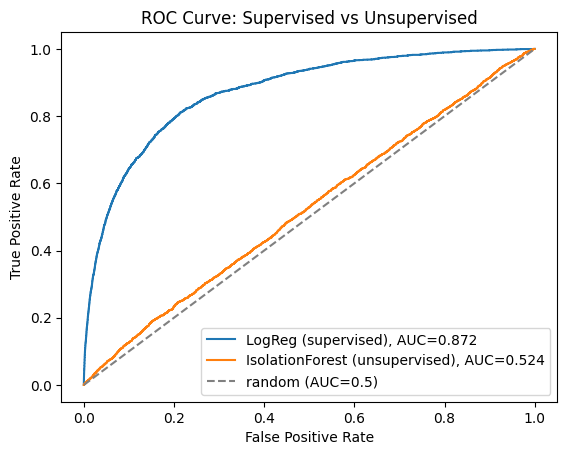

LogReg ROC-AUC:          0.872
IsolationForest ROC-AUC: 0.524


In [40]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# scores for the same test set, both "higher = more suspicious"
auc_logreg = roc_auc_score(y_test, y_proba)
auc_iso    = roc_auc_score(y_test, iso_scores)

for name, scores, auc in [('LogReg (supervised)', y_proba, auc_logreg),
                          ('IsolationForest (unsupervised)', iso_scores, auc_iso)]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    plt.plot(fpr, tpr, label=f'{name}, AUC={auc:.3f}')

plt.plot([0, 1], [0, 1], ls='--', color='gray', label='random (AUC=0.5)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Supervised vs Unsupervised')
plt.legend(); plt.show()

print(f"LogReg ROC-AUC:          {auc_logreg:.3f}")
print(f"IsolationForest ROC-AUC: {auc_iso:.3f}")

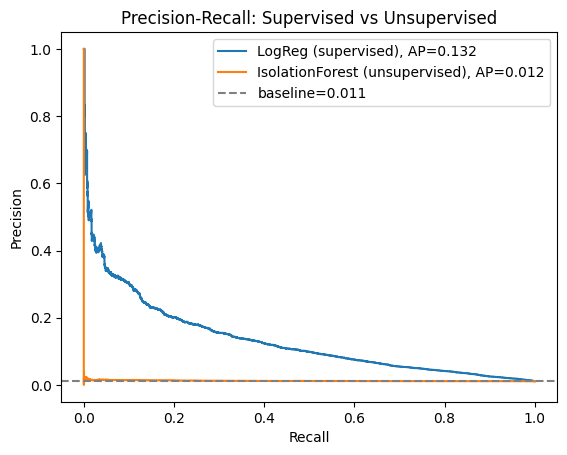

In [41]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

ap_logreg = average_precision_score(y_test, y_proba)
ap_iso    = average_precision_score(y_test, iso_scores)
baseline  = y_test.mean()

for name, scores, ap in [('LogReg (supervised)', y_proba, ap_logreg),
                          ('IsolationForest (unsupervised)', iso_scores, ap_iso)]:
    p, r, _ = precision_recall_curve(y_test, scores)
    plt.plot(r, p, label=f'{name}, AP={ap:.3f}')

plt.axhline(baseline, ls='--', color='gray', label=f'baseline={baseline:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall: Supervised vs Unsupervised')
plt.legend(); plt.show()

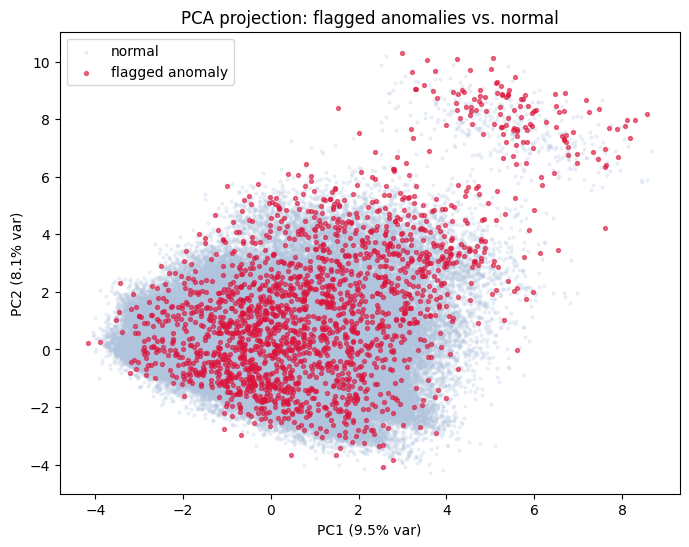

Variance explained by 2 components: 0.176


In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Use the SAME preprocessed features the model saw
X_proc = full_pipeline.named_steps['preprocessor'].transform(X_test)

# 2. PCA down to 2 components
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_proc)

# 3. Anomaly flag: top ~1% most anomalous by your iso_scores
threshold = np.quantile(iso_scores, 0.99)   # top 1% most suspicious
is_anomaly = iso_scores >= threshold

# 4. Plot: normal in light, anomalies on top in red
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[~is_anomaly, 0], X_2d[~is_anomaly, 1], s=4, alpha=0.2, label='normal', color='lightsteelblue')
plt.scatter(X_2d[is_anomaly, 0],  X_2d[is_anomaly, 1],  s=8, alpha=0.6, label='flagged anomaly', color='crimson')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('PCA projection: flagged anomalies vs. normal')
plt.legend(); plt.show()

print("Variance explained by 2 components:", pca.explained_variance_ratio_.sum().round(3))

we used PCA to find the anomaly detection results  at first it seemed like we found something big as all the anomalies found in the top left of the graph, but then I noticed I didn't run the data cleaning yet and that's why we found the anomalies, as we all can see now we haven't found anything.


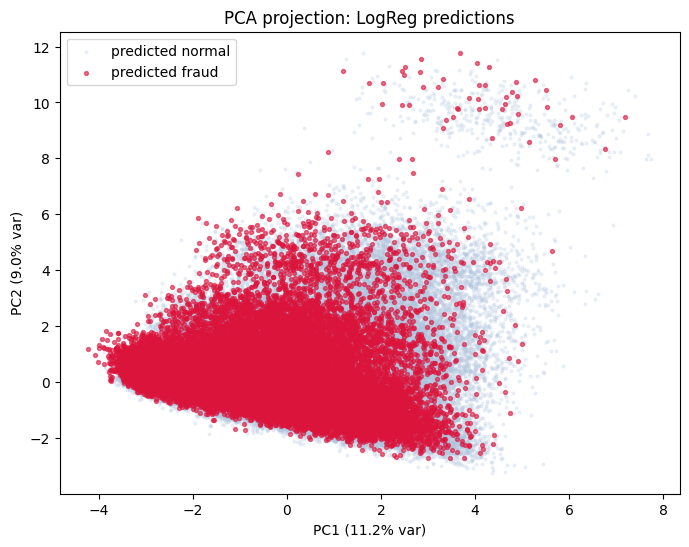

In [44]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Same preprocessed features + same PCA projection as before
X_proc = best_model.named_steps['preprocessor'].transform(X_test)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_proc)

# Logistic regression's fraud predictions (needs a threshold)
y_pred = (y_proba >= 0.5).astype(int)   # 1 = predicted fraud, 0 = predicted normal

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[y_pred == 0, 0], X_2d[y_pred == 0, 1], s=4, alpha=0.2, label='predicted normal', color='lightsteelblue')
plt.scatter(X_2d[y_pred == 1, 0], X_2d[y_pred == 1, 1], s=8, alpha=0.6, label='predicted fraud', color='crimson')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('PCA projection: LogReg predictions')
plt.legend(); plt.show()

We want to make sure our results make sence, so we are going to see how each column affected our final result. 
maybe also have some interesting insights on relation between data we thought is unrelated before

In [45]:
y_pred = (y_proba >= 0.5).astype(int)
print("flagged as fraud:", y_pred.mean())        # fraction flagged
print("actual fraud rate:", y_test.mean())       # ~0.011

flagged as fraud: 0.202715
actual fraud rate: 0.01103


In [46]:
from sklearn.metrics import confusion_matrix
y_pred = (y_proba >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"Recall (fraud caught): {tp/(tp+fn):.1%}")
print(f"Precision (of flagged, real fraud): {tp/(tp+fp):.1%}")
print(f"Fraud missed (false negatives): {fn}")

Recall (fraud caught): 78.8%
Precision (of flagged, real fraud): 4.3%
Fraud missed (false negatives): 467


In [ ]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_model.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print(coef_df)

sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10))
plt.title('Top 10 Most Important Features')
plt.show()

Now we build another model but now we have the results so it is a supervised model and then we will compare them and compare each model to the valid results